In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)
from xgboost import XGBClassifier
import pickle

In [2]:
# Load Dataset

df = pd.read_csv("loan_prediction.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
# Handling Missing Values

df.fillna({
    'Gender': df['Gender'].mode()[0],
    'Married': df['Married'].mode()[0],
    'Dependents': df['Dependents'].mode()[0],
    'Self_Employed': df['Self_Employed'].mode()[0],
    'LoanAmount': df['LoanAmount'].median(),
    'Loan_Amount_Term': df['Loan_Amount_Term'].mode()[0],
    'Credit_History': df['Credit_History'].mode()[0]
}, inplace=True)

print("Missing Values After Treatment:\n")
print(df.isnull().sum())

Missing Values After Treatment:

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [4]:
# Feature Engineering


df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = df['Dependents'].astype(int)
df['TotalIncome'] = (
    df['ApplicantIncome']
    + df['CoapplicantIncome']
)
df['IncomePerDependent'] = (
    df['TotalIncome']
    / (df['Dependents'] + 1)
)
df['LoanIncomeRatio'] = (
    df['LoanAmount']
    / (df['TotalIncome'] + 1)
)
df['EMI'] = (
    df['LoanAmount']
    / df['Loan_Amount_Term']
)
df['BalanceIncome'] = (
    df['TotalIncome']
    - df['EMI']
)

import numpy as np
df['LoanAmount_log'] = np.log1p(
    df['LoanAmount']
)
df['TotalIncome_log'] = np.log1p(
    df['TotalIncome']
)
print("Feature Engineering Completed")
df.head()

Feature Engineering Completed


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomePerDependent,LoanIncomeRatio,EMI,BalanceIncome,LoanAmount_log,TotalIncome_log
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0,5849.0,0.021880,0.355556,5848.644444,4.859812,8.674197
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,3045.5,0.021011,0.355556,6090.644444,4.859812,8.714732
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,3000.0,0.021993,0.183333,2999.816667,4.204693,8.006701
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,4941.0,0.024282,0.333333,4940.666667,4.795791,8.505525
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,6000.0,0.023496,0.391667,5999.608333,4.955827,8.699681


In [5]:
df.drop('Loan_ID', axis=1, inplace=True)

In [6]:
# One hot encoding

df = pd.get_dummies(
    df,
    drop_first=True
)
df.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,IncomePerDependent,LoanIncomeRatio,EMI,BalanceIncome,LoanAmount_log,TotalIncome_log,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,0,5849,0.0,128.0,360.0,1.0,5849.0,5849.0,0.021880,0.355556,5848.644444,4.859812,8.674197,True,False,False,False,False,True,True
1,1,4583,1508.0,128.0,360.0,1.0,6091.0,3045.5,0.021011,0.355556,6090.644444,4.859812,8.714732,True,True,False,False,False,False,False
2,0,3000,0.0,66.0,360.0,1.0,3000.0,3000.0,0.021993,0.183333,2999.816667,4.204693,8.006701,True,True,False,True,False,True,True
3,0,2583,2358.0,120.0,360.0,1.0,4941.0,4941.0,0.024282,0.333333,4940.666667,4.795791,8.505525,True,True,True,False,False,True,True
4,0,6000,0.0,141.0,360.0,1.0,6000.0,6000.0,0.023496,0.391667,5999.608333,4.955827,8.699681,True,False,False,False,False,True,True


In [9]:
X = df.drop('Loan_Status_Y', axis=1)
y = df['Loan_Status_Y']

In [10]:
# Train, test, split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [26]:
# Logistic regression

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(
    solver='liblinear',
    max_iter=5000,
    random_state=42
)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
lr_acc = accuracy_score(
    y_test,
    pred_lr
)
print("Logistic Regression Accuracy:",
      round(lr_acc*100,2), "%")

Logistic Regression Accuracy: 86.18 %


In [15]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
rf_acc = accuracy_score(
    y_test,
    pred_rf
)
print("Random Forest Accuracy:",
      round(rf_acc*100,2), "%")

Random Forest Accuracy: 84.55 %


In [16]:
# Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
gb_acc = accuracy_score(
    y_test,
    pred_gb
)
print("Gradient Boosting Accuracy:",
      round(gb_acc*100,2), "%")

Gradient Boosting Accuracy: 85.37 %


In [17]:
# XGBoost

xgb = XGBClassifier(
    n_estimators=150,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.5,
    reg_lambda=2,
    random_state=42
)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, pred_xgb)
print(
    "XGBoost Accuracy:",
    round(xgb_acc*100,2),
    "%"
)

XGBoost Accuracy: 85.37 %


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
results = pd.DataFrame({

    'Model':[
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost'
    ],
    'Accuracy':[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_rf),
        accuracy_score(y_test,pred_gb),
        accuracy_score(y_test,pred_xgb)
    ],
    'Precision':[
        precision_score(y_test,pred_lr),
        precision_score(y_test,pred_rf),
        precision_score(y_test,pred_gb),
        precision_score(y_test,pred_xgb)
    ],
    'Recall':[
        recall_score(y_test,pred_lr),
        recall_score(y_test,pred_rf),
        recall_score(y_test,pred_gb),
        recall_score(y_test,pred_xgb)
    ],
    'F1 Score':[
        f1_score(y_test,pred_lr),
        f1_score(y_test,pred_rf),
        f1_score(y_test,pred_gb),
        f1_score(y_test,pred_xgb)
    ]
})
results.iloc[:,1:] = results.iloc[:,1:] * 100
results.round(2)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,86.18,84.00,98.82,90.81
1,Random Forest,84.55,90.24,87.06,88.62
2,Gradient Boosting,85.37,86.81,92.94,89.77
3,XGBoost,85.37,83.17,98.82,90.32


In [19]:
# Classification Report

from sklearn.metrics import classification_report
print("Classification Report\n")
print(
    classification_report(
        y_test,
        pred_lr
    )
)

Classification Report

              precision    recall  f1-score   support

       False       0.96      0.58      0.72        38
        True       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



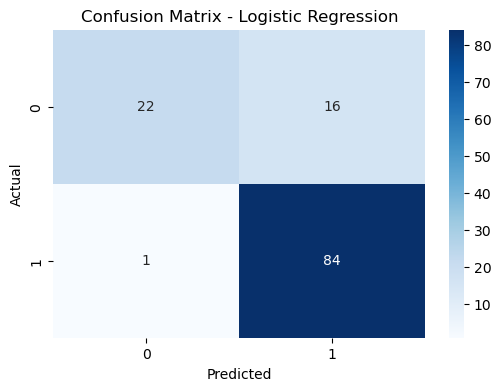

In [20]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(
    y_test,
    pred_lr
)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title(
    "Confusion Matrix - Logistic Regression"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [21]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
feature_importance.head(10)

,Feature,Importance
5,Credit_History,0.336341
7,IncomePerDependent,0.082715
8,LoanIncomeRatio,0.069461
4,Loan_Amount_Term,0.066101
2,CoapplicantIncome,0.063344
17,Property_Area_Semiurban,0.060145
1,ApplicantIncome,0.055776
14,Married_Yes,0.050572
3,LoanAmount,0.049161
15,Education_Not Graduate,0.045304


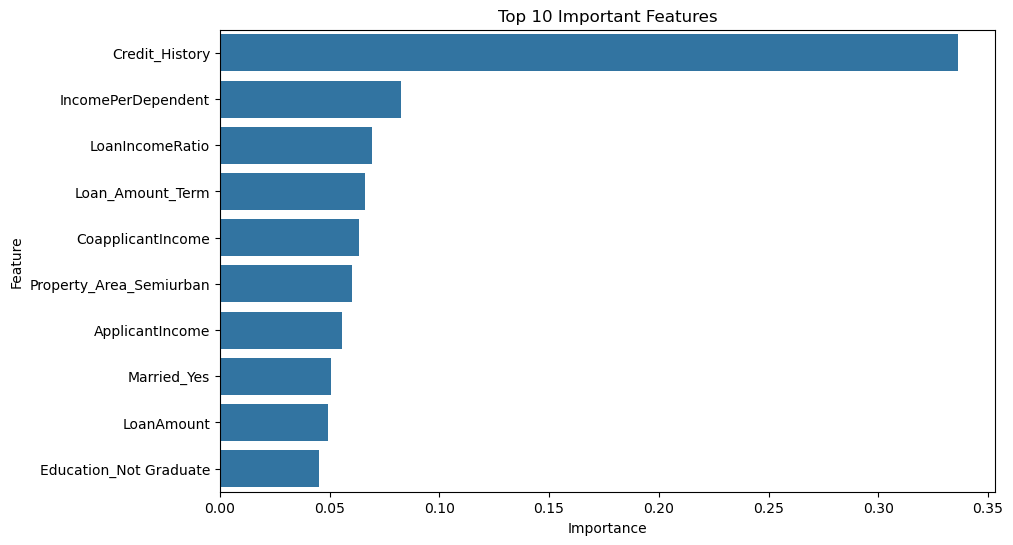

In [22]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)
plt.title(
    "Top 10 Important Features"
)
plt.show()

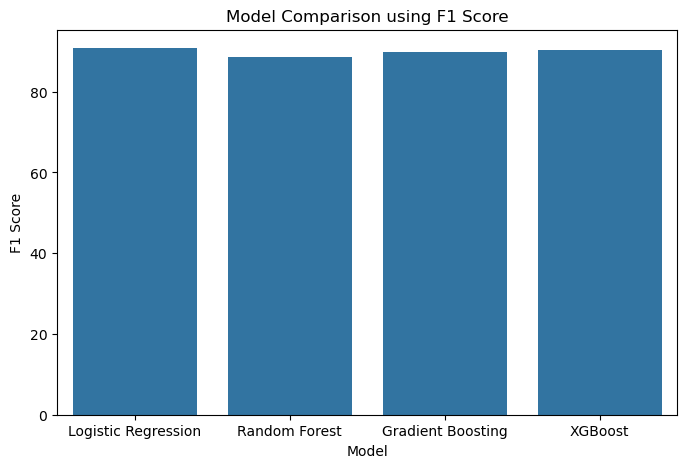

In [23]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=results,
    x='Model',
    y='F1 Score'
)
plt.title(
    "Model Comparison using F1 Score"
)
plt.show()

In [24]:
best_model = results.loc[
    results['F1 Score'].idxmax()
]
print(f"Final Model Selected: {best_model['Model']}")
print(f"Accuracy : {best_model['Accuracy']:.2f}%")
print(f"Precision: {best_model['Precision']:.2f}%")
print(f"Recall   : {best_model['Recall']:.2f}%")
print(f"F1 Score : {best_model['F1 Score']:.2f}%")
print("\nReason:")
print(f"{best_model['Model']} achieved the highest F1 Score among all evaluated models.")

Final Model Selected: Logistic Regression
Accuracy : 86.18%
Precision: 84.00%
Recall   : 98.82%
F1 Score : 90.81%

Reason:
Logistic Regression achieved the highest F1 Score among all evaluated models.


In [27]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    lr,
    X,
    y,
    cv=10,
    scoring='f1'
)
print(
    "Average Cross Validation F1 Score:",
    round(scores.mean()*100,2),
    "%"
)

Average Cross Validation F1 Score: 86.96 %


In [28]:
import pickle
with open(
    "loan_model.pkl",
    "wb"
) as f:
    pickle.dump(
        lr,
        f
    )
print(
    "Model saved successfully!"
)

Model saved successfully!


In [29]:
with open("feature_names.pkl", "wb") as f:
    pickle.dump(
        X.columns.tolist(),
        f
    )
print("Feature names saved successfully!")

Feature names saved successfully!
